# Import Required Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew, kurtosis

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)

In [3]:
df = pd.read_csv("data/processed/churn_clean.csv")

df.head()

,customer_id,count,country,state,city,zip_code,lat_long,latitude,longitude,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_label,churn_value,churn_score,cltv,churn_reason,age_group,monthly_spend_category,tenure_group,high_value_customer,cltv_segment,churn_risk,payment_mode,internet_category,service_count,engagement_score,customer_status,location,avg_revenue_per_month,coordinates,churn_reason_category,loyalty_level,customer_segment
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer,Adult,Medium,0-12 Months,No,Bronze,High,Offline,DSL,3,48.19,Inactive,"Los Angeles, California",54.075000,"(33.964131, -118.272783)",Churned,New,At Risk
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved,Adult,High,0-12 Months,No,Bronze,Medium,Online,Fiber,1,32.81,Inactive,"Los Angeles, California",75.825000,"(34.059281, -118.30742)",Churned,New,Standard
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved,Adult,High,0-12 Months,Yes,Gold,High,Online,Fiber,5,81.92,Inactive,"Los Angeles, California",102.562500,"(34.048013, -118.293953)",Churned,New,VIP At Risk
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved,Adult,High,24-48 Months,Yes,Gold,High,Online,Fiber,6,91.23,Inactive,"Los Angeles, California",108.787500,"(34.062125, -118.315709)",Churned,Regular,VIP At Risk
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices,Adult,High,48-72 Months,Yes,Gold,High,Online,Fiber,6,103.00,Inactive,"Los Angeles, California",102.781633,"(34.039224, -118.266293)",Churned,Loyal,VIP At Risk


# Dataset Overview

In [5]:
print("Dataset Shape:", df.shape)

print("\n")

print(df.info())

Dataset Shape: (7043, 50)


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             7043 non-null   str    
 1   count                   7043 non-null   int64  
 2   country                 7043 non-null   str    
 3   state                   7043 non-null   str    
 4   city                    7043 non-null   str    
 5   zip_code                7043 non-null   int64  
 6   lat_long                7043 non-null   str    
 7   latitude                7043 non-null   float64
 8   longitude               7043 non-null   float64
 9   gender                  7043 non-null   str    
 10  senior_citizen          7043 non-null   str    
 11  partner                 7043 non-null   str    
 12  dependents              7043 non-null   str    
 13  tenure_months           7043 non-null   int64  
 14  phone_service          

In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,7043,7043,3668-QPYBK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
count,7043.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
country,7043,1,United States,7043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,7043,1,California,7043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,7043,1129,Los Angeles,305,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zip_code,7043.0,NaN,NaN,NaN,93521.964646,1865.794555,90001.0,92102.0,93552.0,95351.0,96161.0
lat_long,7043,1652,"33.964131, -118.272783",5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,7043.0,NaN,NaN,NaN,36.282441,2.455723,32.555828,34.030915,36.391777,38.224869,41.962127
longitude,7043.0,NaN,NaN,NaN,-119.79888,2.157889,-124.301372,-121.815412,-119.730885,-118.043237,-114.192901
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Missing Values Verification

In [7]:
missing = pd.DataFrame({

    "Missing Values": df.isnull().sum(),

    "Percentage": (
        df.isnull().sum() /
        len(df)
    ) * 100

})

missing.sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Percentage
loyalty_level,11,0.156183
total_charges,11,0.156183
tenure_group,11,0.156183
avg_revenue_per_month,11,0.156183
city,0,0.000000
zip_code,0,0.000000
country,0,0.000000
state,0,0.000000
longitude,0,0.000000
gender,0,0.000000


# Duplicate Records Verification

In [8]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [9]:
numerical_columns = df.select_dtypes(include=np.number).columns

df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
count,7043.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
zip_code,7043.0,93521.964646,1865.794555,90001.000000,92102.000000,93552.000000,95351.000000,96161.000000
latitude,7043.0,36.282441,2.455723,32.555828,34.030915,36.391777,38.224869,41.962127
longitude,7043.0,-119.798880,2.157889,-124.301372,-121.815412,-119.730885,-118.043237,-114.192901
tenure_months,7043.0,32.371149,24.559481,0.000000,9.000000,29.000000,55.000000,72.000000
monthly_charges,7043.0,64.761692,30.090047,18.250000,35.500000,70.350000,89.850000,118.750000
total_charges,7032.0,2283.300441,2266.771362,18.800000,401.450000,1397.475000,3794.737500,8684.800000
churn_value,7043.0,0.265370,0.441561,0.000000,0.000000,0.000000,1.000000,1.000000
churn_score,7043.0,58.699418,21.525131,5.000000,40.000000,61.000000,75.000000,100.000000
cltv,7043.0,4400.295755,1183.057152,2003.000000,3469.000000,4527.000000,5380.500000,6500.000000


In [10]:
statistics = pd.DataFrame({

    "Mean": df[numerical_columns].mean(),

    "Median": df[numerical_columns].median(),

    "Variance": df[numerical_columns].var(),

    "Std Dev": df[numerical_columns].std(),

    "Skewness": df[numerical_columns].apply(skew),

    "Kurtosis": df[numerical_columns].apply(kurtosis)

})

statistics.round(2)

C:\Users\admin\Desktop\New folder\Google_D_A\venv\Lib\site-packages\pandas\core\apply.py:1183: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  results[i] = self.func(v, *self.args, **self.kwargs)
C:\Users\admin\Desktop\New folder\Google_D_A\venv\Lib\site-packages\pandas\core\apply.py:1183: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  results[i] = self.func(v, *self.args, **self.kwargs)


,Mean,Median,Variance,Std Dev,Skewness,Kurtosis
count,1.00,1.00,0.00,0.00,NaN,NaN
zip_code,93521.96,93552.00,3481189.32,1865.79,-0.25,-1.15
latitude,36.28,36.39,6.03,2.46,0.30,-1.14
longitude,-119.80,-119.73,4.66,2.16,-0.04,-1.14
tenure_months,32.37,29.00,603.17,24.56,0.24,-1.39
monthly_charges,64.76,70.35,905.41,30.09,-0.22,-1.26
total_charges,2283.30,1397.48,5138252.41,2266.77,NaN,NaN
churn_value,0.27,0.00,0.19,0.44,1.06,-0.87
churn_score,58.70,61.00,463.33,21.53,-0.09,-1.01
cltv,4400.30,4527.00,1399624.22,1183.06,-0.31,-0.93


## Customer Churn Distribution

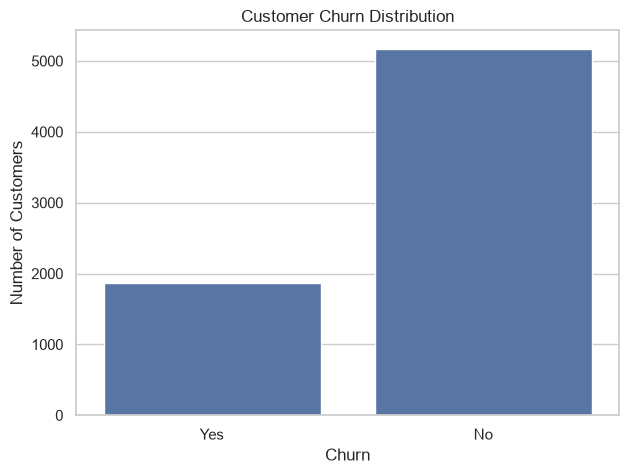

In [13]:
plt.figure(figsize=(7,5))

sns.countplot(data=df,x="churn_label")

plt.title("Customer Churn Distribution")

plt.xlabel("Churn")

plt.ylabel("Number of Customers")

plt.show()

In [15]:
print(df.columns.tolist())

['customer_id', 'count', 'country', 'state', 'city', 'zip_code', 'lat_long', 'latitude', 'longitude', 'gender', 'senior_citizen', 'partner', 'dependents', 'tenure_months', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method', 'monthly_charges', 'total_charges', 'churn_label', 'churn_value', 'churn_score', 'cltv', 'churn_reason', 'age_group', 'monthly_spend_category', 'tenure_group', 'high_value_customer', 'cltv_segment', 'churn_risk', 'payment_mode', 'internet_category', 'service_count', 'engagement_score', 'customer_status', 'location', 'avg_revenue_per_month', 'coordinates', 'churn_reason_category', 'loyalty_level', 'customer_segment']


In [16]:
churn_percentage = (

    df["churn_label"]

    .value_counts(normalize=True)

    *100

)

print(churn_percentage.round(2))

churn_label
No     73.46
Yes    26.54
Name: proportion, dtype: float64


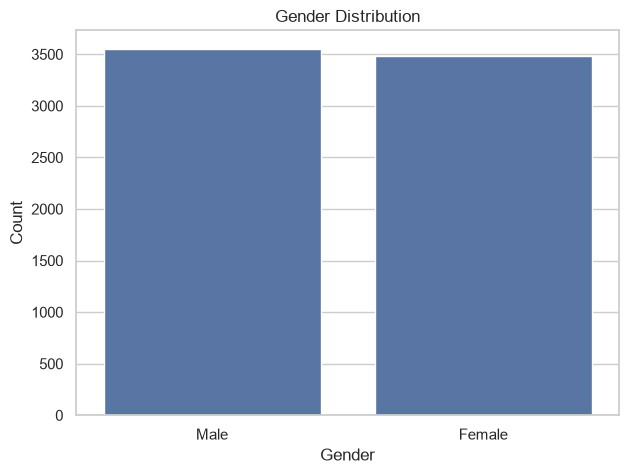

In [17]:
plt.figure(figsize=(7,5))

sns.countplot(

    data=df,

    x="gender"

)

plt.title("Gender Distribution")

plt.xlabel("Gender")

plt.ylabel("Count")

plt.show()

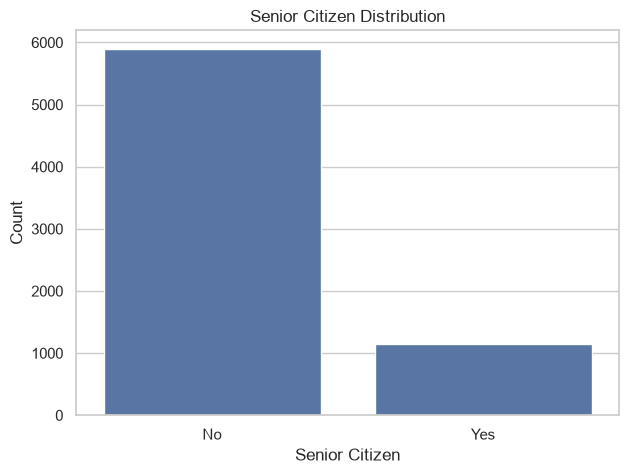

In [18]:
plt.figure(figsize=(7,5))

sns.countplot(

    data=df,

    x="senior_citizen"

)

plt.title("Senior Citizen Distribution")

plt.xlabel("Senior Citizen")

plt.ylabel("Count")

plt.show()

# Contract Type Distribution

C:\Users\admin\AppData\Local\Temp\ipykernel_9268\2209829365.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


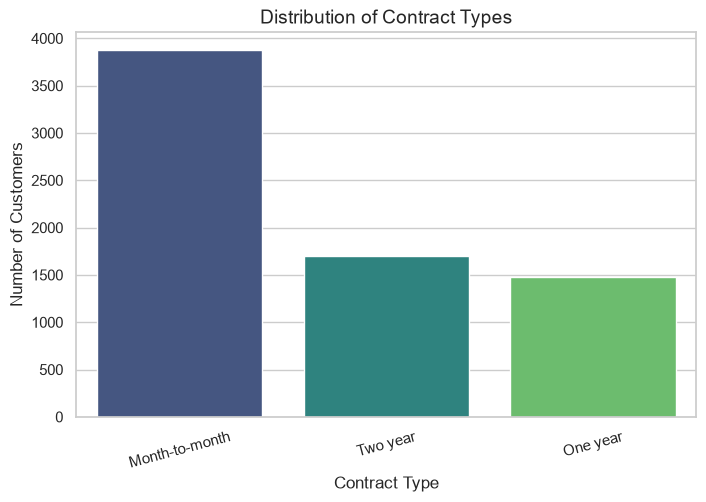

In [19]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="contract",
    order=df["contract"].value_counts().index,
    palette="viridis"
)

plt.title("Distribution of Contract Types", fontsize=14)
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)

plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_9268\2473251133.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


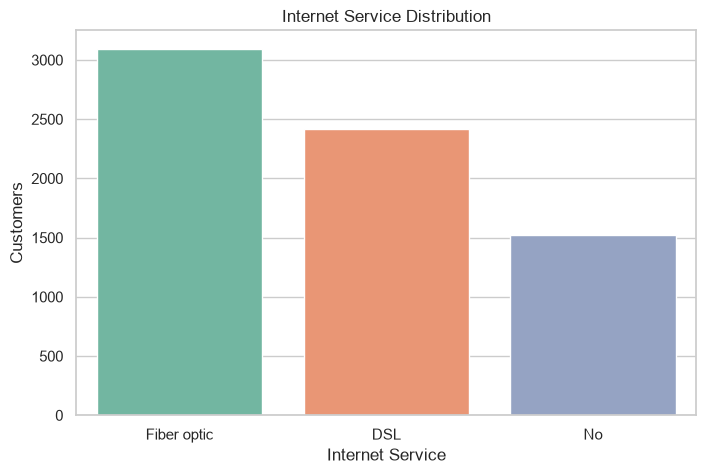

In [20]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="internet_service",
    order=df["internet_service"].value_counts().index,
    palette="Set2"
)

plt.title("Internet Service Distribution")

plt.xlabel("Internet Service")

plt.ylabel("Customers")

plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_9268\1528502524.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


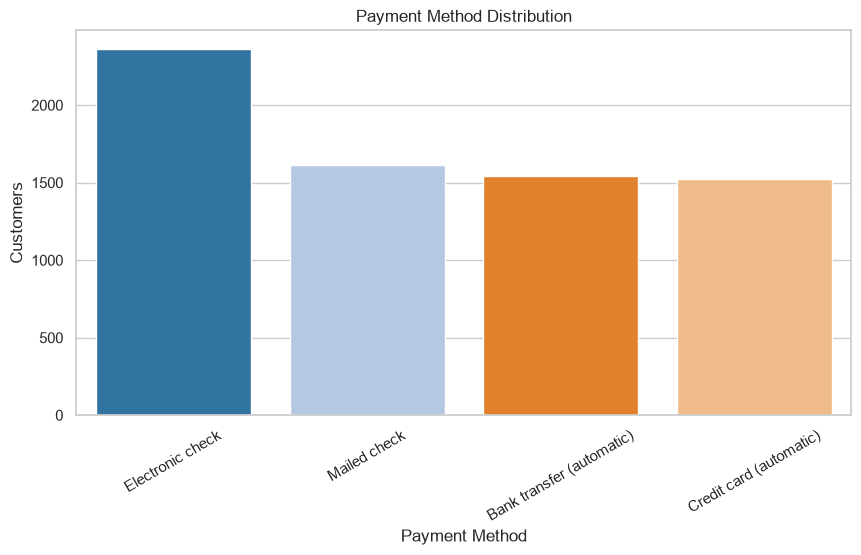

In [21]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="payment_method",
    order=df["payment_method"].value_counts().index,
    palette="tab20"
)

plt.xticks(rotation=30)

plt.title("Payment Method Distribution")

plt.xlabel("Payment Method")

plt.ylabel("Customers")

plt.show()


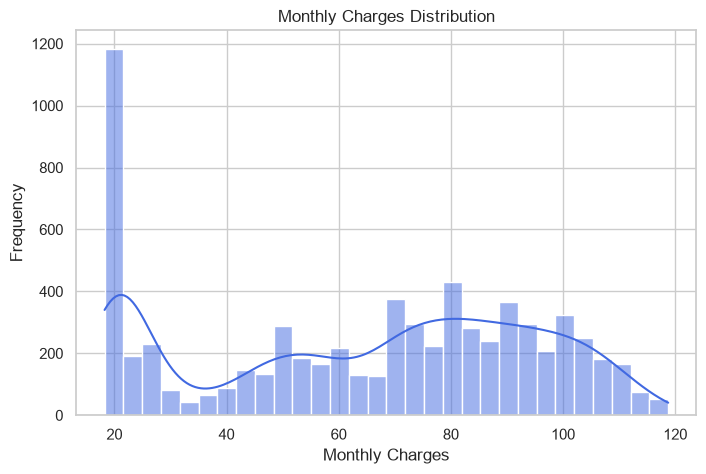

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["monthly_charges"],
    bins=30,
    kde=True,
    color="royalblue"
)

plt.title("Monthly Charges Distribution")

plt.xlabel("Monthly Charges")

plt.ylabel("Frequency")

plt.show()

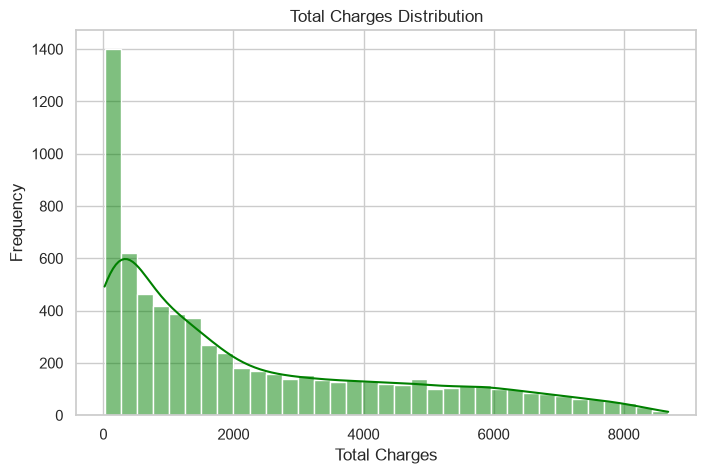

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["total_charges"],
    bins=35,
    kde=True,
    color="green"
)

plt.title("Total Charges Distribution")

plt.xlabel("Total Charges")

plt.ylabel("Frequency")

plt.show()

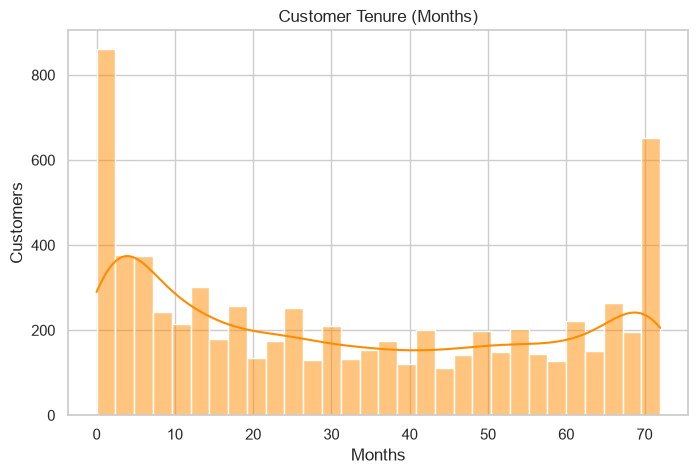

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["tenure_months"],
    bins=30,
    kde=True,
    color="darkorange"
)

plt.title("Customer Tenure (Months)")

plt.xlabel("Months")

plt.ylabel("Customers")

plt.show()

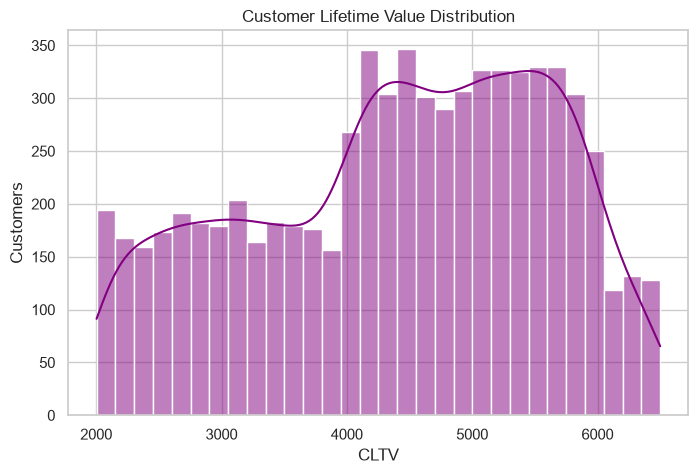

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["cltv"],
    bins=30,
    kde=True,
    color="purple"
)

plt.title("Customer Lifetime Value Distribution")

plt.xlabel("CLTV")

plt.ylabel("Customers")

plt.show()

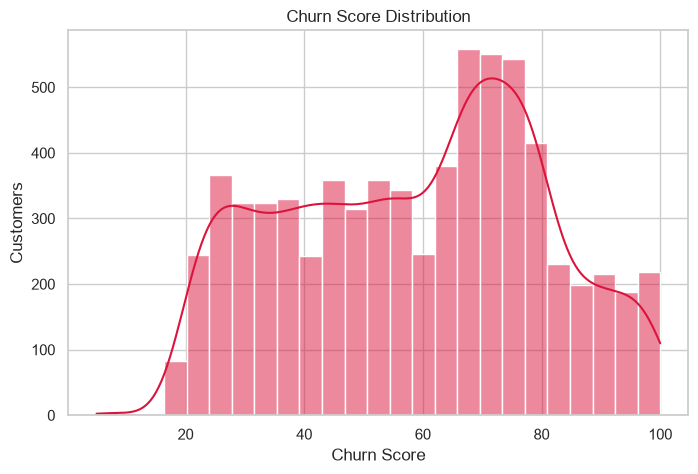

In [26]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["churn_score"],
    bins=25,
    kde=True,
    color="crimson"
)

plt.title("Churn Score Distribution")

plt.xlabel("Churn Score")

plt.ylabel("Customers")

plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_9268\2218166795.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


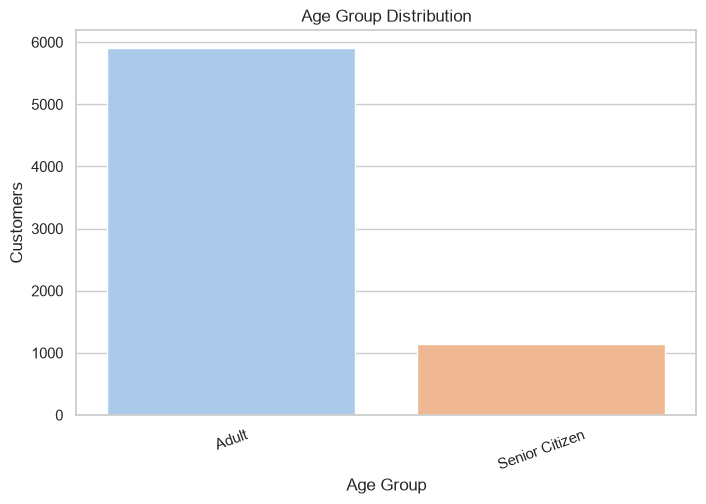

In [27]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="age_group",
    order=df["age_group"].value_counts().index,
    palette="pastel"
)

plt.title("Age Group Distribution")

plt.xlabel("Age Group")

plt.ylabel("Customers")

plt.xticks(rotation=20)

plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_9268\1649015699.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


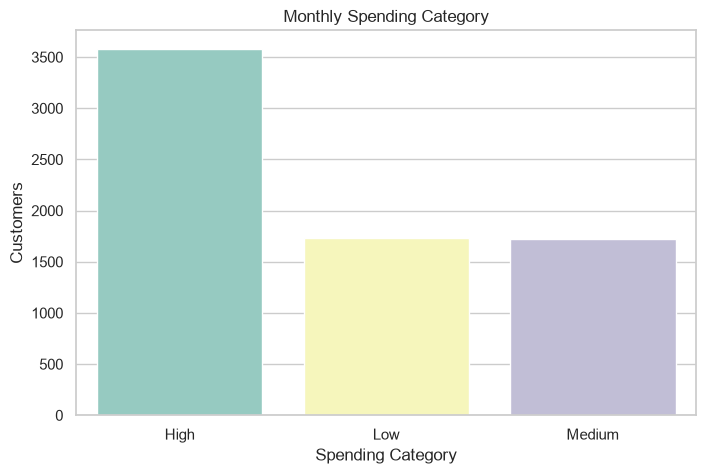

In [28]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="monthly_spend_category",
    order=df["monthly_spend_category"].value_counts().index,
    palette="Set3"
)

plt.title("Monthly Spending Category")

plt.xlabel("Spending Category")

plt.ylabel("Customers")

plt.show()

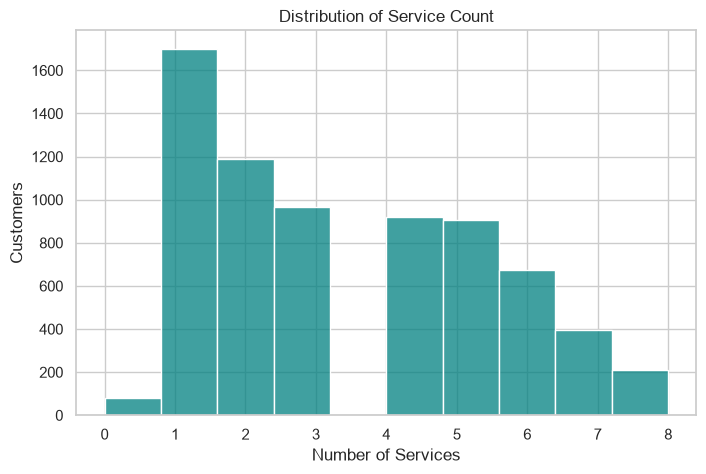

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["service_count"],
    bins=10,
    kde=False,
    color="teal"
)

plt.title("Distribution of Service Count")

plt.xlabel("Number of Services")

plt.ylabel("Customers")

plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_9268\2865412993.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


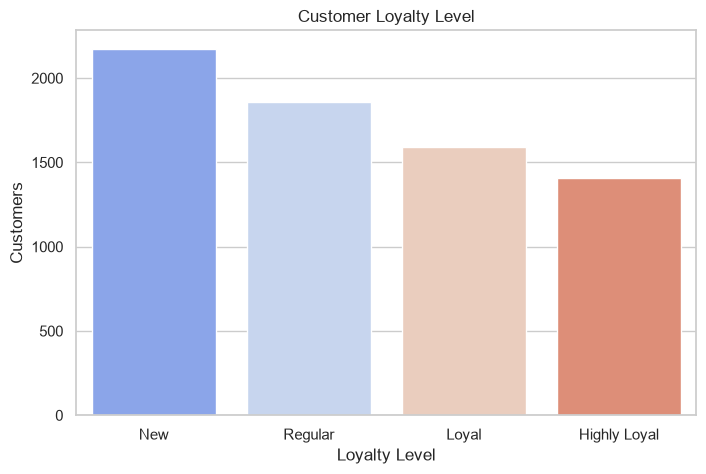

In [30]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="loyalty_level",
    order=df["loyalty_level"].value_counts().index,
    palette="coolwarm"
)

plt.title("Customer Loyalty Level")

plt.xlabel("Loyalty Level")

plt.ylabel("Customers")

plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_9268\1538740020.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


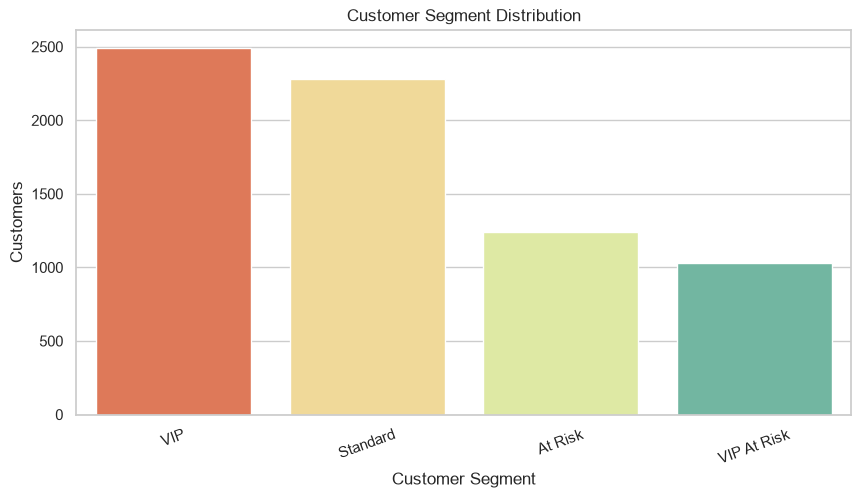

In [31]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="customer_segment",
    order=df["customer_segment"].value_counts().index,
    palette="Spectral"
)

plt.title("Customer Segment Distribution")

plt.xlabel("Customer Segment")

plt.ylabel("Customers")

plt.xticks(rotation=20)

plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_9268\3057755573.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


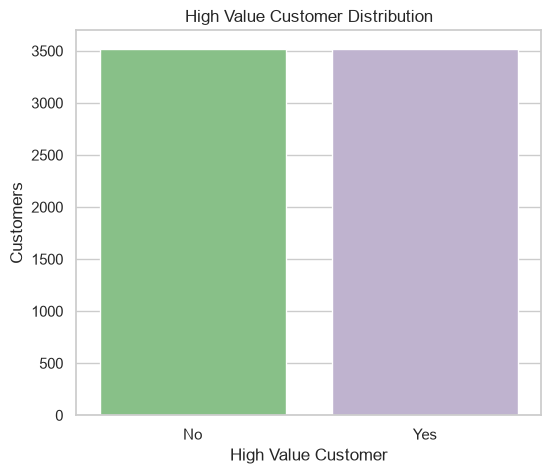

In [32]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="high_value_customer",
    palette="Accent"
)

plt.title("High Value Customer Distribution")

plt.xlabel("High Value Customer")

plt.ylabel("Customers")

plt.show()

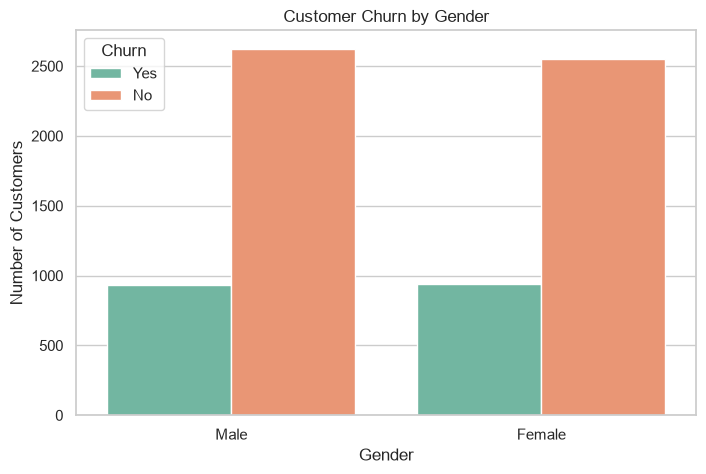

In [33]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="gender",
    hue="churn_label",
    palette="Set2"
)

plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")

plt.show()

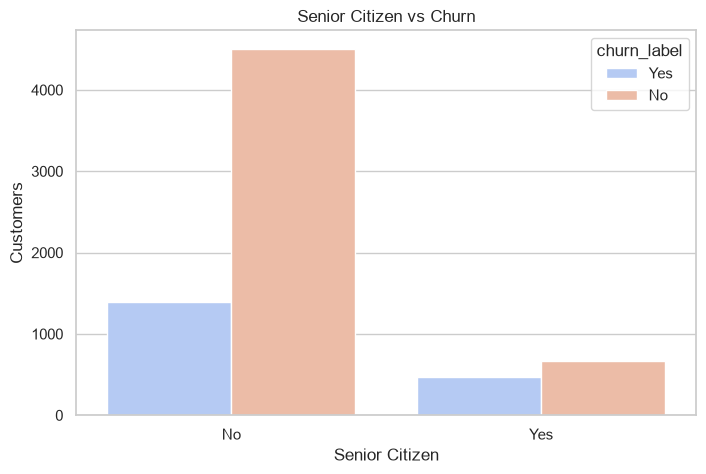

In [34]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="senior_citizen",
    hue="churn_label",
    palette="coolwarm"
)

plt.title("Senior Citizen vs Churn")

plt.xlabel("Senior Citizen")

plt.ylabel("Customers")

plt.show()

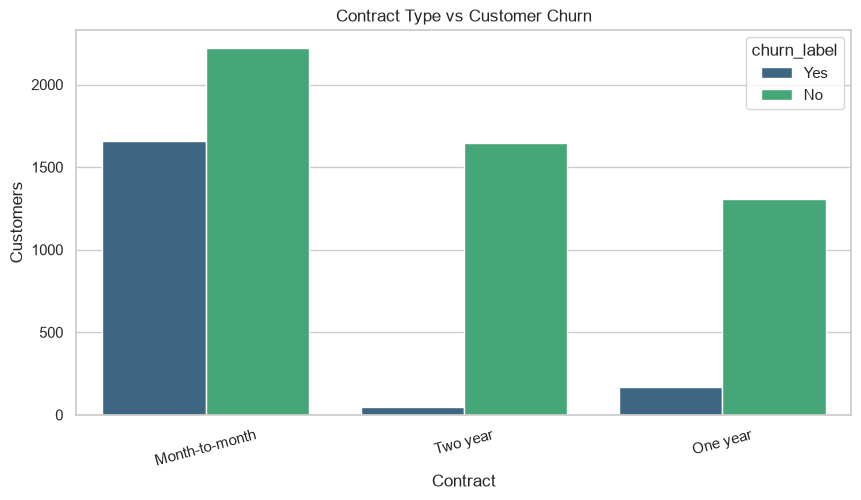

In [35]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="contract",
    hue="churn_label",
    palette="viridis"
)

plt.title("Contract Type vs Customer Churn")

plt.xlabel("Contract")

plt.ylabel("Customers")

plt.xticks(rotation=15)

plt.show()

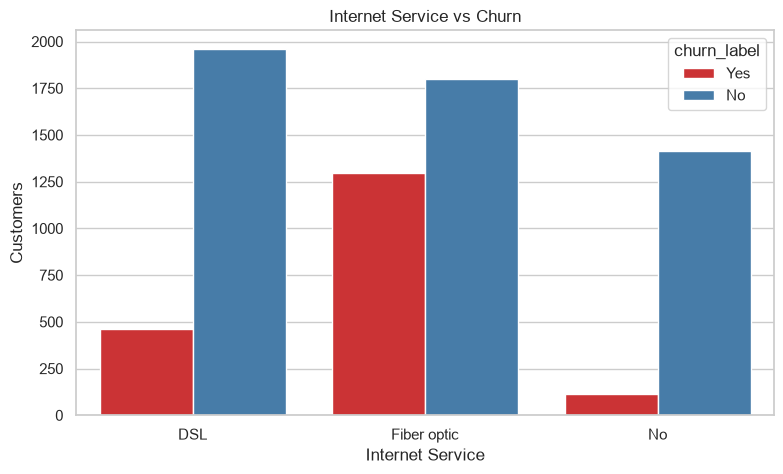

In [36]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x="internet_service",
    hue="churn_label",
    palette="Set1"
)

plt.title("Internet Service vs Churn")

plt.xlabel("Internet Service")

plt.ylabel("Customers")

plt.show()

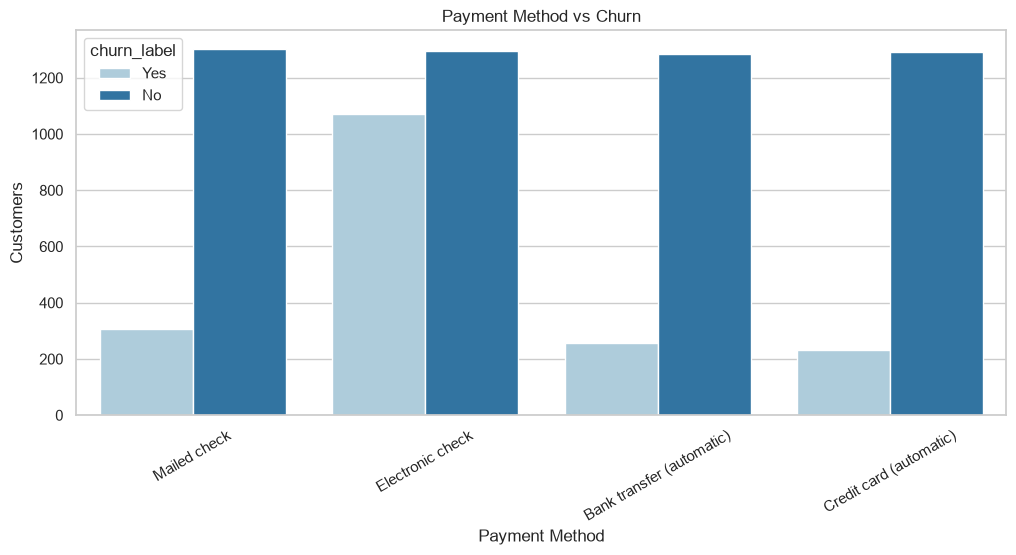

In [37]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x="payment_method",
    hue="churn_label",
    palette="Paired"
)

plt.xticks(rotation=30)

plt.title("Payment Method vs Churn")

plt.xlabel("Payment Method")

plt.ylabel("Customers")

plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_9268\3192596076.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


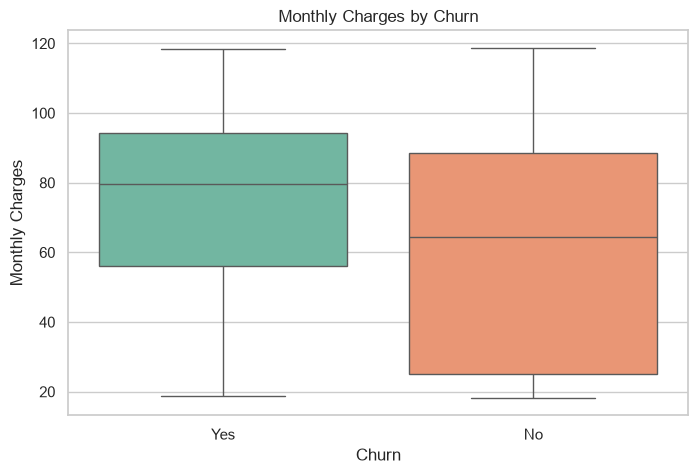

In [38]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="churn_label",
    y="monthly_charges",
    palette="Set2"
)

plt.title("Monthly Charges by Churn")

plt.xlabel("Churn")

plt.ylabel("Monthly Charges")

plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_9268\3465163456.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


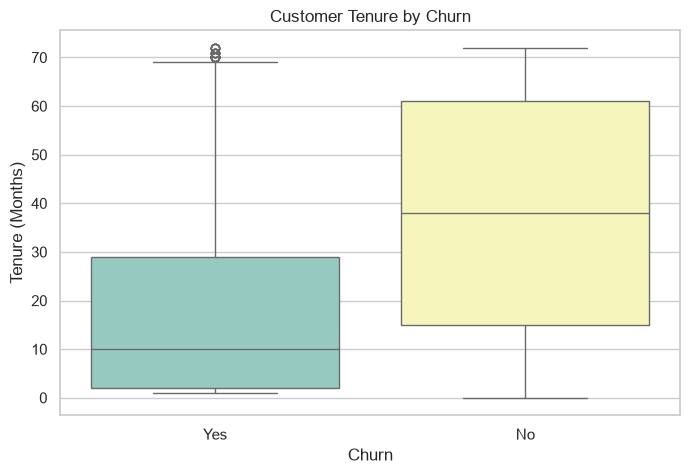

In [39]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="churn_label",
    y="tenure_months",
    palette="Set3"
)

plt.title("Customer Tenure by Churn")

plt.xlabel("Churn")

plt.ylabel("Tenure (Months)")

plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_9268\3660729333.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


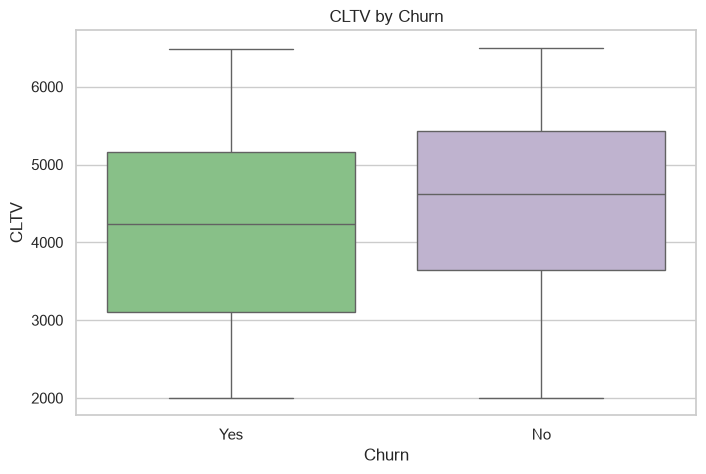

In [40]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="churn_label",
    y="cltv",
    palette="Accent"
)

plt.title("CLTV by Churn")

plt.xlabel("Churn")

plt.ylabel("CLTV")

plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_9268\1167559212.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


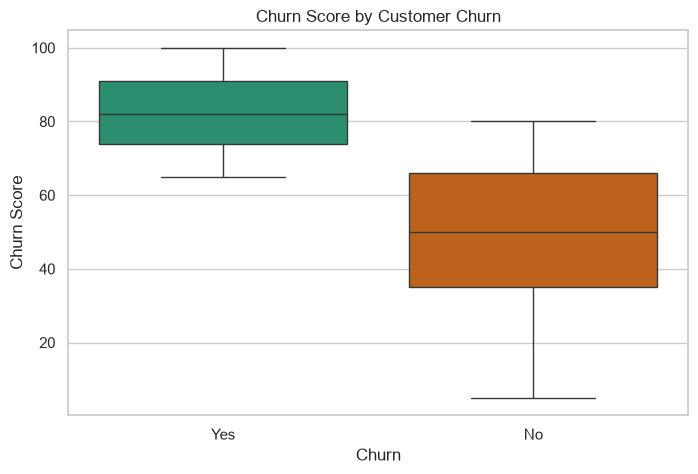

In [41]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="churn_label",
    y="churn_score",
    palette="Dark2"
)

plt.title("Churn Score by Customer Churn")

plt.xlabel("Churn")

plt.ylabel("Churn Score")

plt.show()

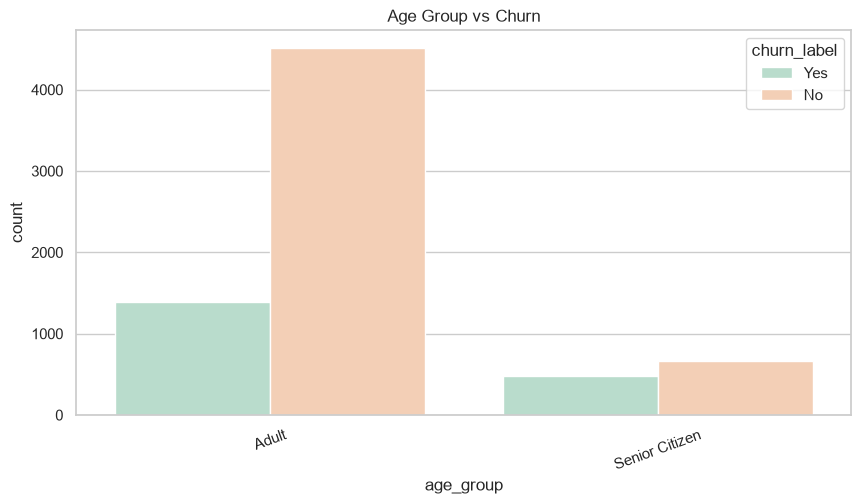

In [42]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="age_group",
    hue="churn_label",
    palette="Pastel2"
)

plt.title("Age Group vs Churn")

plt.xticks(rotation=20)

plt.show()

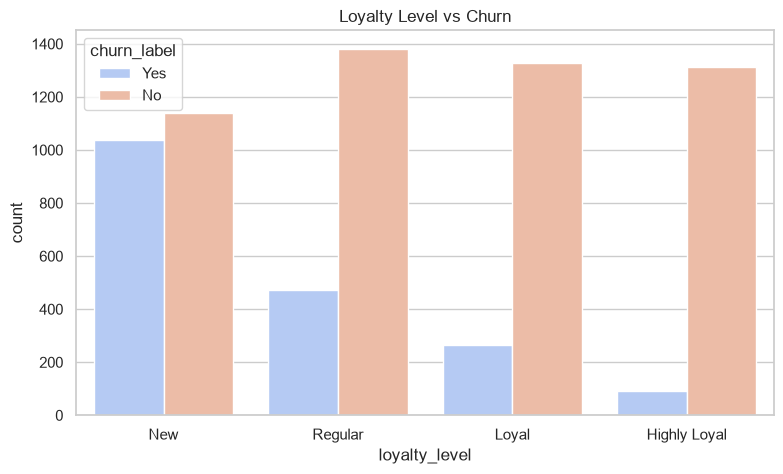

In [43]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x="loyalty_level",
    hue="churn_label",
    palette="coolwarm"
)

plt.title("Loyalty Level vs Churn")

plt.show()

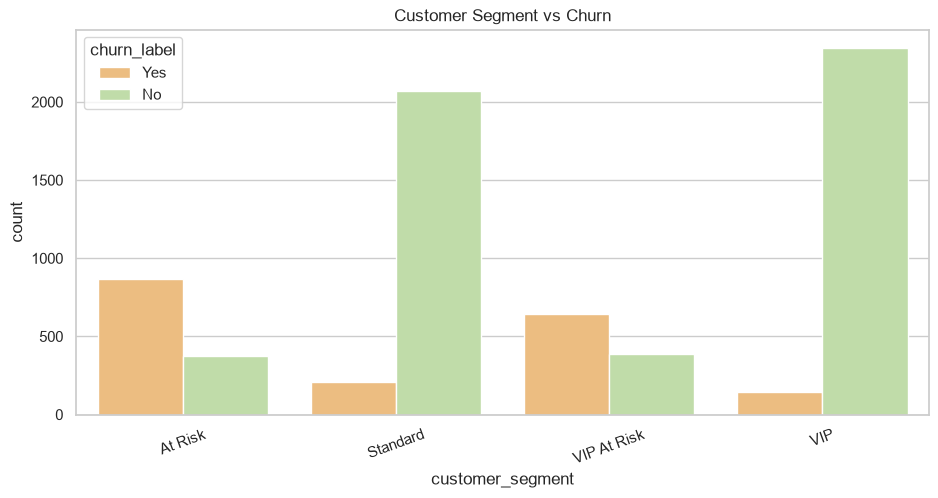

In [44]:
plt.figure(figsize=(11,5))

sns.countplot(
    data=df,
    x="customer_segment",
    hue="churn_label",
    palette="Spectral"
)

plt.xticks(rotation=20)

plt.title("Customer Segment vs Churn")

plt.show()

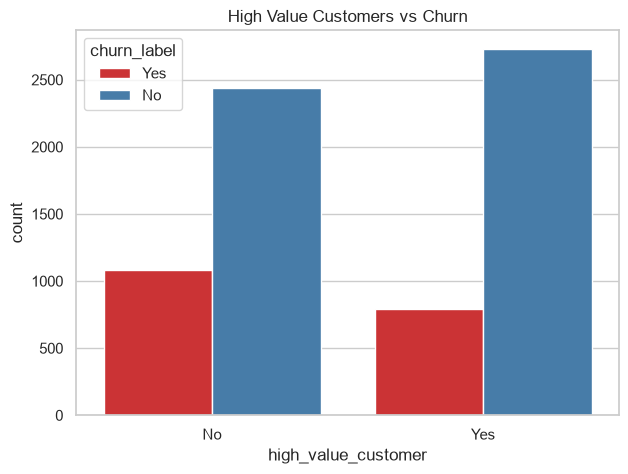

In [45]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="high_value_customer",
    hue="churn_label",
    palette="Set1"
)

plt.title("High Value Customers vs Churn")

plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_9268\3790993899.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


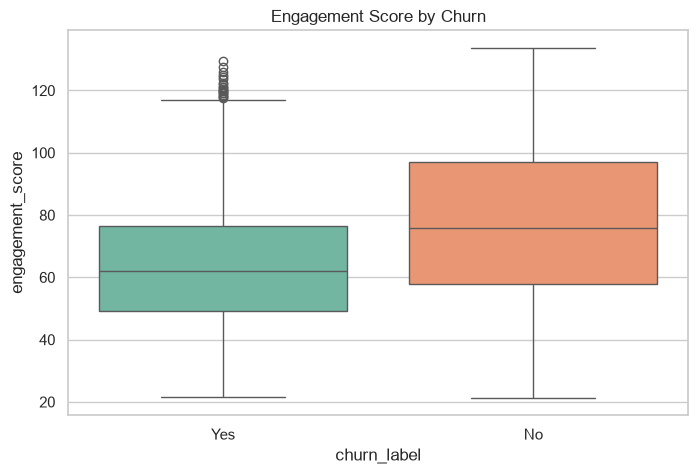

In [46]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="churn_label",
    y="engagement_score",
    palette="Set2"
)

plt.title("Engagement Score by Churn")

plt.show()

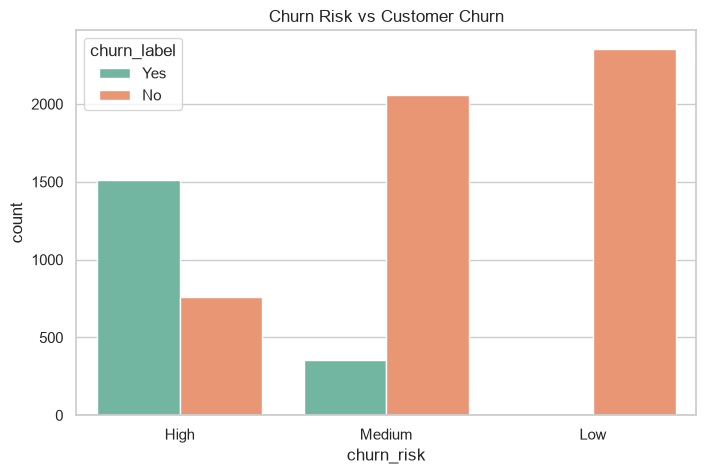

In [47]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="churn_risk",
    hue="churn_label",
    palette="Set2"
)

plt.title("Churn Risk vs Customer Churn")

plt.show()

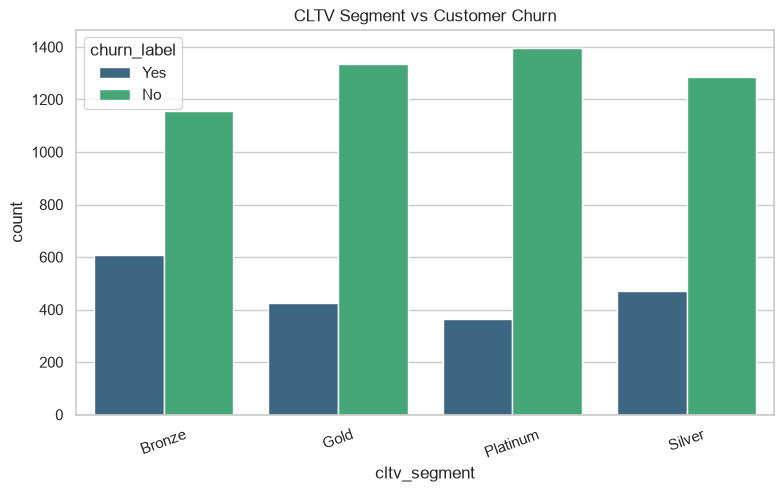

In [48]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x="cltv_segment",
    hue="churn_label",
    palette="viridis"
)

plt.title("CLTV Segment vs Customer Churn")

plt.xticks(rotation=20)

plt.show()

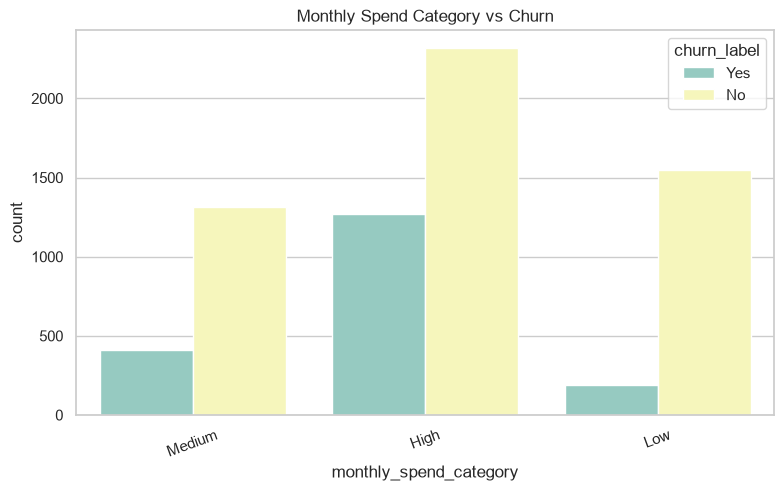

In [49]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x="monthly_spend_category",
    hue="churn_label",
    palette="Set3"
)

plt.title("Monthly Spend Category vs Churn")

plt.xticks(rotation=20)

plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_9268\1392753719.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


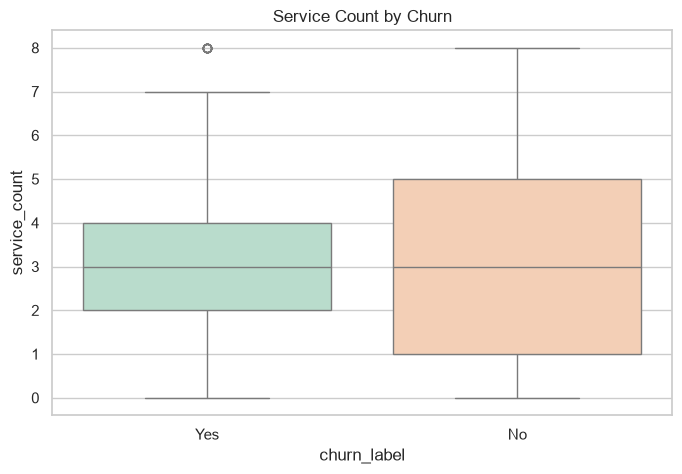

In [50]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="churn_label",
    y="service_count",
    palette="Pastel2"
)

plt.title("Service Count by Churn")

plt.show()

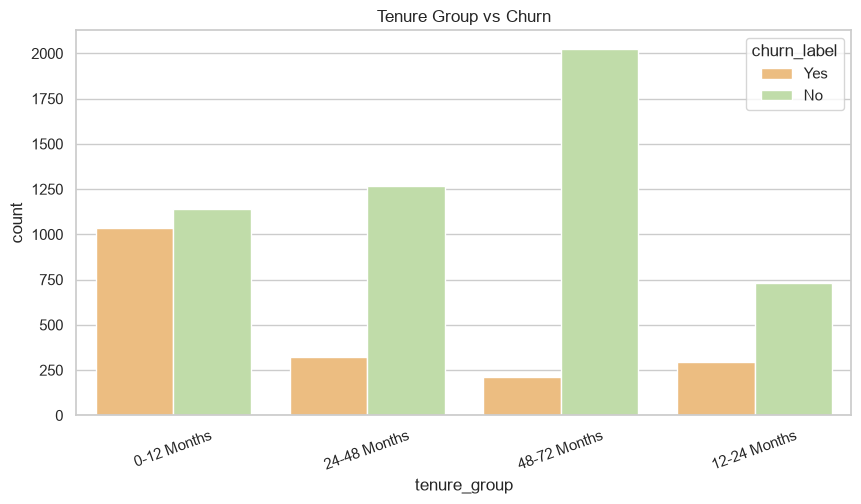

In [51]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="tenure_group",
    hue="churn_label",
    palette="Spectral"
)

plt.title("Tenure Group vs Churn")

plt.xticks(rotation=20)

plt.show()

## HeatMap

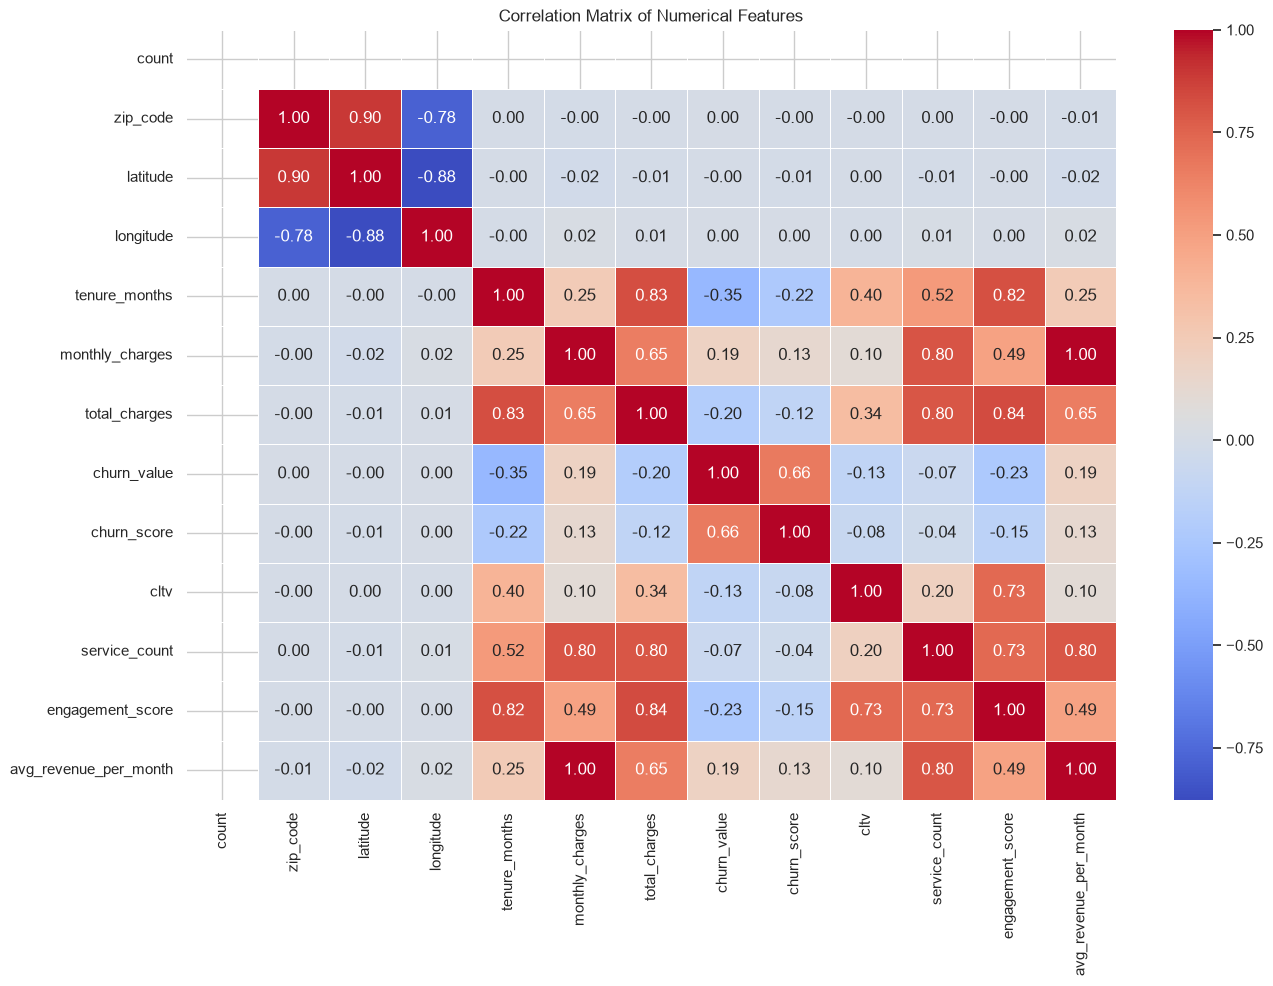

In [52]:
plt.figure(figsize=(15,10))

numeric_df = df.select_dtypes(include=["int64", "float64"])

correlation = numeric_df.corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Features")

plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_9268\1822158697.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


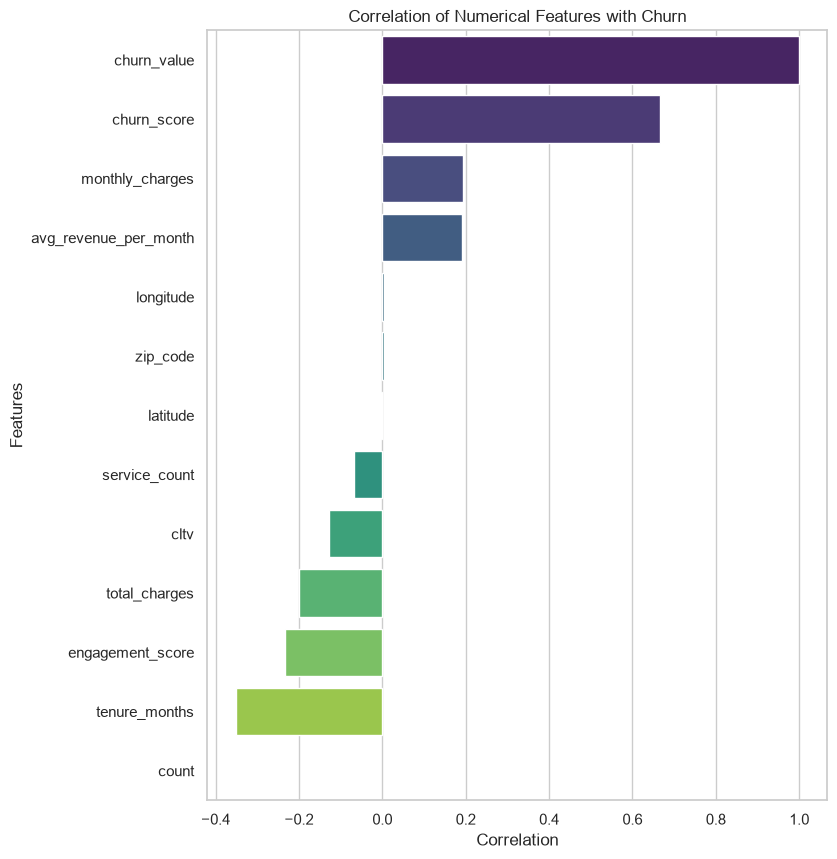

In [53]:

churn_corr = (
    numeric_df.corr()["churn_value"]
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,10))

sns.barplot(
    x=churn_corr.values,
    y=churn_corr.index,
    palette="viridis"
)

plt.title("Correlation of Numerical Features with Churn")

plt.xlabel("Correlation")

plt.ylabel("Features")

plt.show()

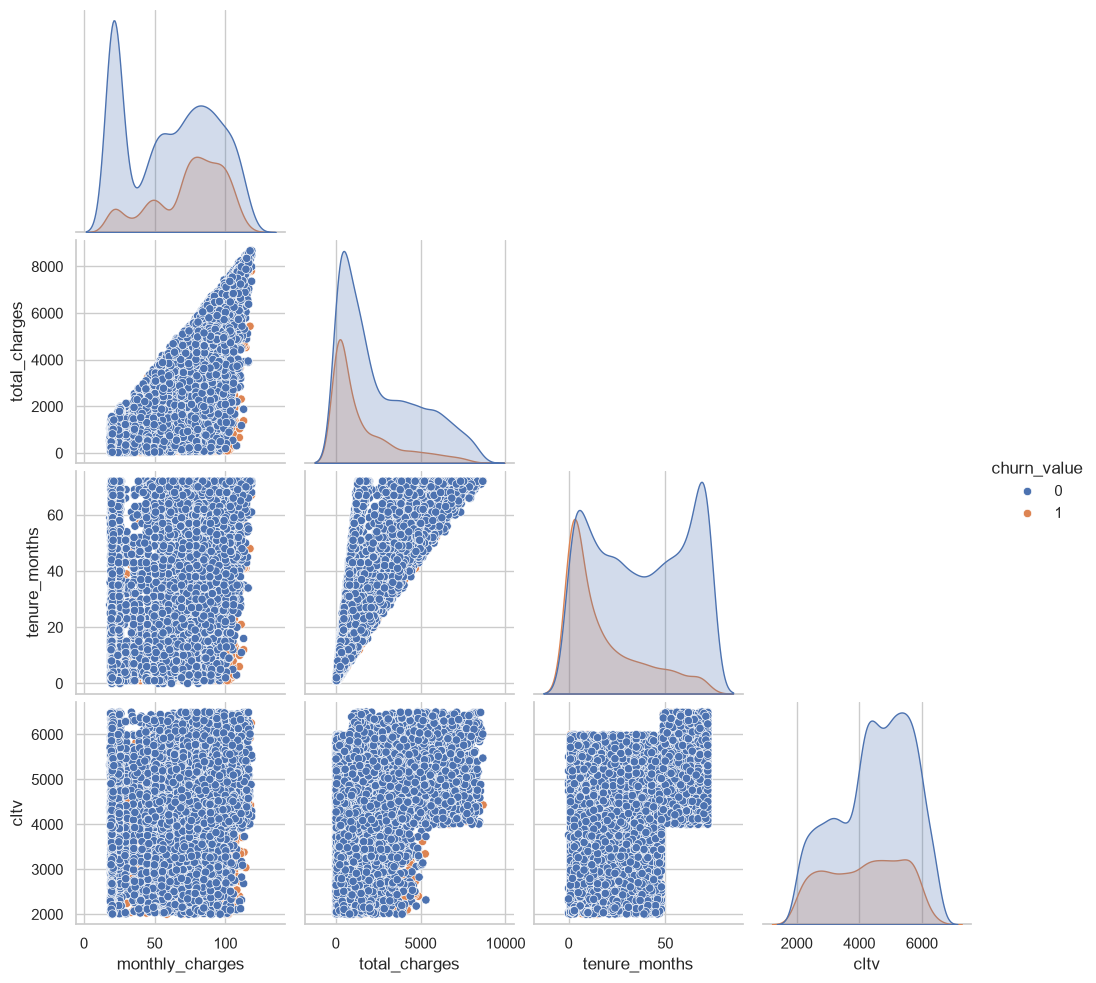

In [54]:
pairplot_columns = [
    "monthly_charges",
    "total_charges",
    "tenure_months",
    "cltv",
    "churn_value"
]

sns.pairplot(
    df[pairplot_columns],
    hue="churn_value",
    corner=True
)

plt.show()

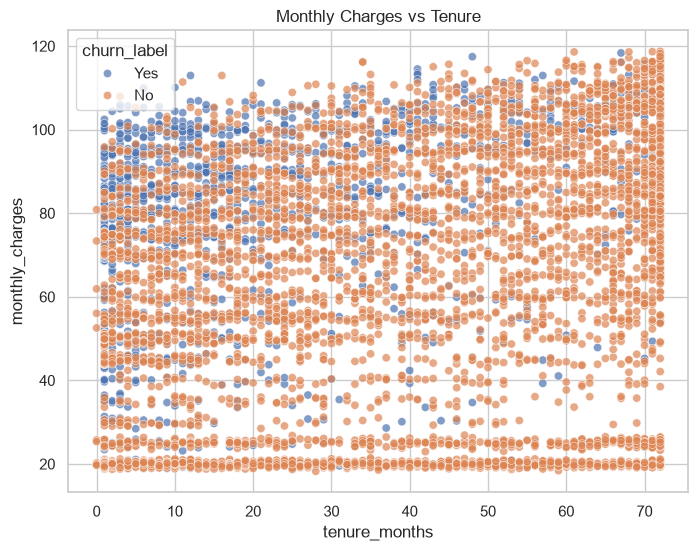

In [55]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="tenure_months",
    y="monthly_charges",
    hue="churn_label",
    alpha=0.7
)

plt.title("Monthly Charges vs Tenure")

plt.show()

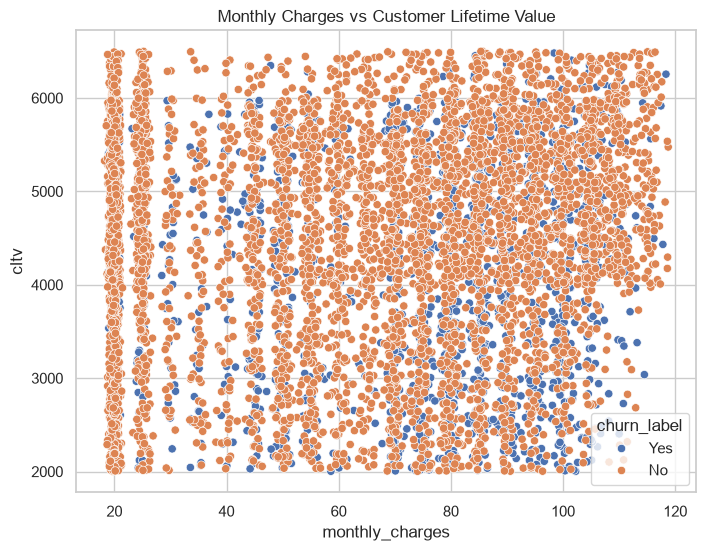

In [56]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="monthly_charges",
    y="cltv",
    hue="churn_label"
)

plt.title("Monthly Charges vs Customer Lifetime Value")

plt.show()

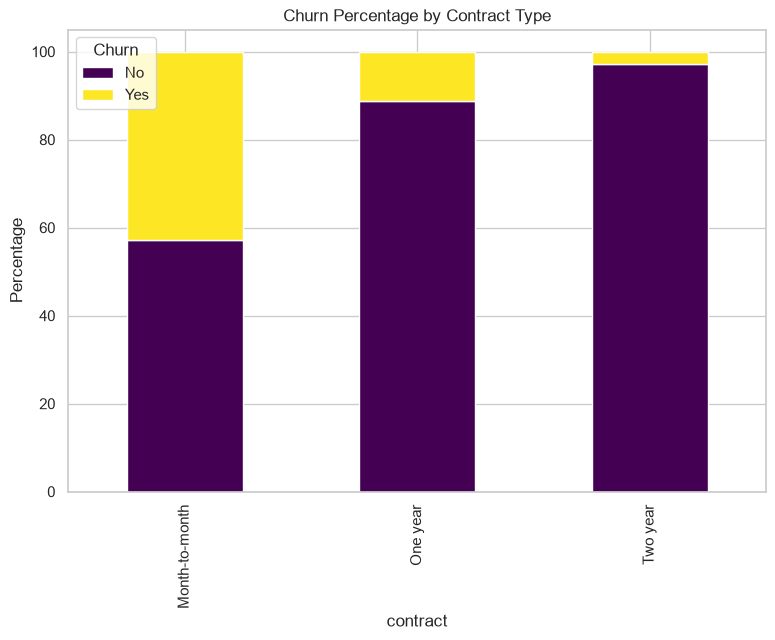

In [57]:
contract_churn = pd.crosstab(
    df["contract"],
    df["churn_label"],
    normalize="index"
) * 100

contract_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(9,6),
    colormap="viridis"
)

plt.ylabel("Percentage")

plt.title("Churn Percentage by Contract Type")

plt.legend(title="Churn")

plt.show()

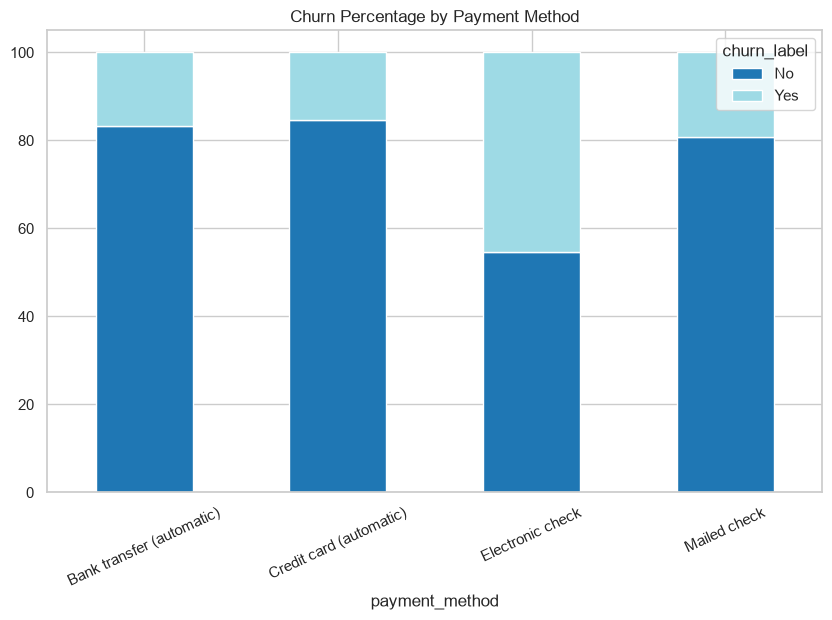

In [58]:
payment_churn = pd.crosstab(
    df["payment_method"],
    df["churn_label"],
    normalize="index"
) * 100

payment_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6),
    colormap="tab20"
)

plt.xticks(rotation=25)

plt.title("Churn Percentage by Payment Method")

plt.show()

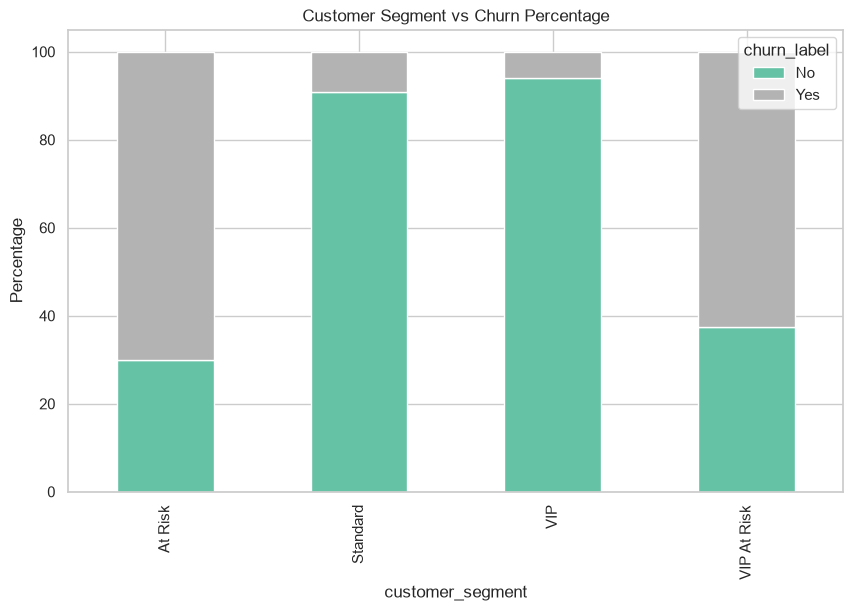

In [59]:
segment = pd.crosstab(
    df["customer_segment"],
    df["churn_label"],
    normalize="index"
) * 100

segment.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6),
    colormap="Set2"
)

plt.title("Customer Segment vs Churn Percentage")

plt.ylabel("Percentage")

plt.show()

In [60]:
pivot = pd.pivot_table(
    df,
    values="monthly_charges",
    index="contract",
    columns="churn_label",
    aggfunc="mean"
)

display(pivot)

churn_label,No,Yes
contract,,
Month-to-month,61.462635,73.019396
One year,62.508148,85.050904
Two year,60.012477,86.777083


In [61]:
pivot = pd.pivot_table(
    df,
    values="cltv",
    index="customer_segment",
    aggfunc=["mean","median","max"]
)

display(pivot)

,mean,median,max
,cltv,cltv,cltv
customer_segment,,,
At Risk,3359.420629,3383.0,4526
Standard,3438.527632,3522.5,4526
VIP,5402.873194,5392.5,6500
VIP At Risk,5357.707767,5357.0,6491


In [62]:
summary = pd.DataFrame({

    "Metric":[
        "Total Customers",
        "Customers Churned",
        "Retention Rate (%)",
        "Average Monthly Charges",
        "Average CLTV",
        "Average Tenure"
    ],

    "Value":[

        len(df),

        (df["churn_label"]=="Yes").sum(),

        round(
            (df["churn_label"]=="No").mean()*100,
            2
        ),

        round(df["monthly_charges"].mean(),2),

        round(df["cltv"].mean(),2),

        round(df["tenure_months"].mean(),2)

    ]

})

display(summary)

,Metric,Value
0,Total Customers,7043.00
1,Customers Churned,1869.00
2,Retention Rate (%),73.46
3,Average Monthly Charges,64.76
4,Average CLTV,4400.30
5,Average Tenure,32.37


In [63]:
top_corr = (
    correlation["churn_value"]
    .abs()
    .sort_values(ascending=False)
)

display(top_corr)

churn_value              1.000000
churn_score              0.664897
tenure_months            0.352229
engagement_score         0.232990
total_charges            0.199484
monthly_charges          0.193356
avg_revenue_per_month    0.192033
cltv                     0.127463
service_count            0.067264
longitude                0.004594
latitude                 0.003384
zip_code                 0.003346
count                         NaN
Name: churn_value, dtype: float64

# Executive Business Insights

## Key Findings

- Month-to-month contract customers exhibit the highest churn rates.
- Customers with shorter tenure are significantly more likely to churn.
- Higher monthly charges are associated with increased churn probability.
- Lower engagement scores correspond to higher churn.
- High-value customers generally demonstrate better retention.
- Customer segmentation reveals distinct behavioral patterns useful for targeted retention campaigns.
- Loyalty level is strongly associated with customer retention.
- Engineered features such as churn risk, customer segment, and service count provide additional predictive power.

# Business Recommendations

- Encourage customers to switch to longer-term contracts.
- Improve onboarding and engagement for new customers.
- Offer retention discounts to customers with high monthly charges.
- Prioritize high-risk customers for proactive retention campaigns.
- Increase customer engagement through personalized services and loyalty programs.
- Focus customer support efforts on high-value customers to maximize retention.

### Conclusion

This exploratory data analysis identified the major factors influencing customer churn and uncovered meaningful relationships between customer demographics, service usage, financial metrics, and engineered business features.

The analysis demonstrates that contract type, tenure, monthly charges, customer lifetime value, engagement score, and loyalty level are among the strongest indicators of churn.

The insights generated in this notebook provide a solid foundation for feature engineering, SQL-based business analytics, and predictive machine learning models that will be developed in the subsequent stages of the project.